### **K-Means Clustering using Diabetes Health Indicators**

In [1]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


#### **Load Diabetes Data**
- The Behavioral Risk Factor Surveillance System (BRFSS) is a healthrelated telephone survey that is collected annually by the CDC,
- It is a refined dataset containing 253,680 survey responses to the CDC's BRFSS2015
- Link to the data: [Kaggle Dataset](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset?select=diabetes_012_health_indicators_BRFSS2015.csv)

In [4]:
diabetes_df = pd.read_csv('../data/diabetes_brfss2015.csv')
diabetes_df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
print("Shape of the dataset:", diabetes_df.shape)

Shape of the dataset: (253680, 22)


In [6]:
print("Columns in the dataset:", diabetes_df.columns.tolist())

Columns in the dataset: ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [8]:
# Drop the label column ("Diabetes_012") since clustering is unsupervised
X = diabetes_df.drop(columns=["Diabetes_012"])

In [9]:
# Keep only numeric features
X = X.select_dtypes(include=[np.number])

In [10]:
# standardize the features
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

In [16]:
# Downsample for faster silhouette search
X_sample = Xs[np.random.choice(Xs.shape[0], size=100000, replace=False), :]

In [17]:
# try different cluster counts
sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels)
    sil_scores[k] = sil
    print(f"k={k} → silhouette={sil:.3f}")

k=2 → silhouette=0.201
k=3 → silhouette=0.203
k=4 → silhouette=0.090
k=5 → silhouette=0.099
k=6 → silhouette=0.105
k=7 → silhouette=0.099


**Silhoutte Score:**
- This score measures how well the clusters are separated.
- Best score in this case is 0.203 and it is relatively low as the clusters are not very distinct.
- k=2 and k=3 give the best silhouette scores, the score drops from cluster 4.

In [18]:
# fit with best k
best_k = max(sil_scores, key=sil_scores.get)
print("\nBest k by silhouette:", best_k)


Best k by silhouette: 3


In [20]:
# kmeans with best k
km_best = KMeans(n_clusters=best_k, n_init=10, random_state=42)
labels_km = km_best.fit_predict(X_sample)
centroids = km_best.cluster_centers_

In [21]:
# Extra metrics
sil = silhouette_score(X_sample, labels_km)
dbi = davies_bouldin_score(X_sample, labels_km)
chi = calinski_harabasz_score(X_sample, labels_km)

print(f"\nFinal metrics (k={best_k}):")
print(f"Silhouette: {sil:.3f}, Davies-Bouldin: {dbi:.3f}, Calinski-Harabasz: {chi:.1f}")


Final metrics (k=3):
Silhouette: 0.203, Davies-Bouldin: 2.251, Calinski-Harabasz: 9651.3


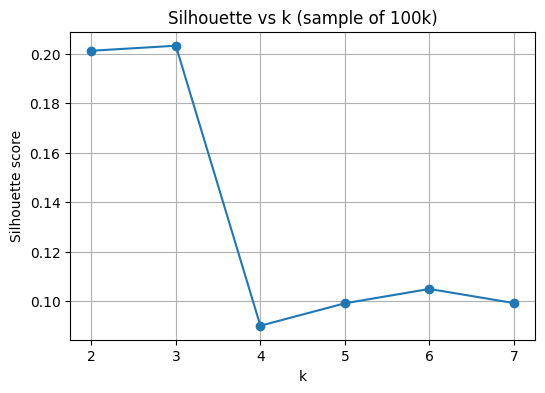

In [24]:
# silhoutte plot vs k value
plt.figure(figsize=(6,4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs k (sample of 100k)")
plt.grid(True)
plt.show()

The above plot shows the variation of silhouette score across multiple clusters (k values)

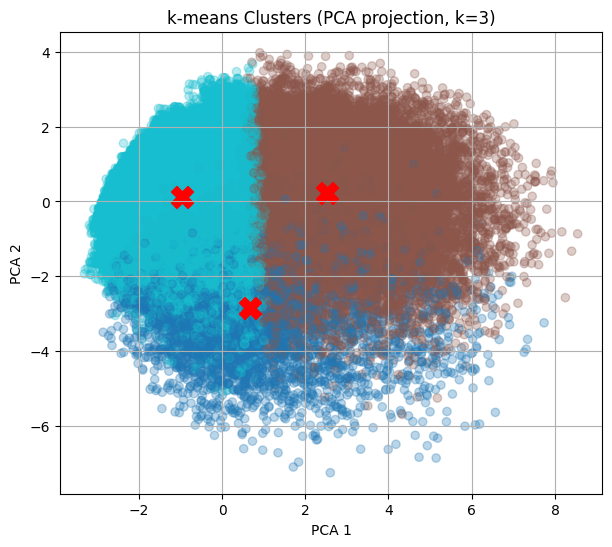

In [22]:
# Visualize clusters with PCA
pca = PCA(n_components=2, random_state=42).fit(X_sample)
XY = pca.transform(X_sample)
CXY = pca.transform(centroids)

plt.figure(figsize=(7,6))
plt.scatter(XY[:,0], XY[:,1], c=labels_km, cmap="tab10", alpha=0.3)
plt.scatter(CXY[:,0], CXY[:,1], marker='X', s=250, c="red")
plt.title(f"k-means Clusters (PCA projection, k={best_k})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()

**PCA Projection Plot**
- The clusters are not completely separated as the overlaps can be seen from the above plot. 
- The brown cluster dominates one side of PCA1 and the blue cluster spreads across left and lower side.
- This overlap reflects the real-world health data where people share many risk factors. 